In [2]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


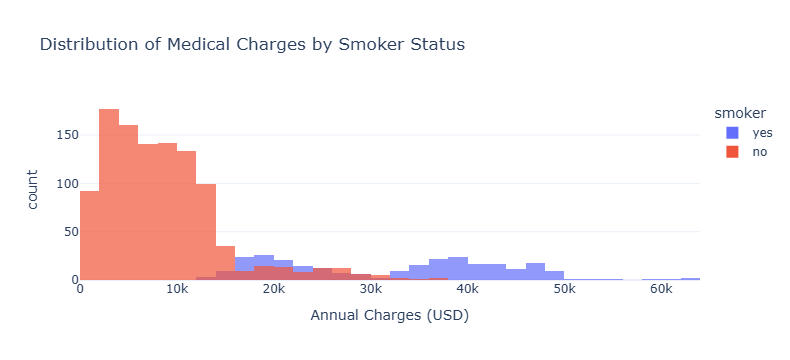

In [3]:
#Charges by smoker status (hover + filter)
fig = px.histogram(
    df,
    x='charges',
    nbins=40,
    color='smoker',
    title='Distribution of Medical Charges by Smoker Status',
    labels={'charges': 'Annual Charges (USD)'},
    barmode='overlay',
    opacity=0.7,
    template='plotly_white'
)
fig.show()

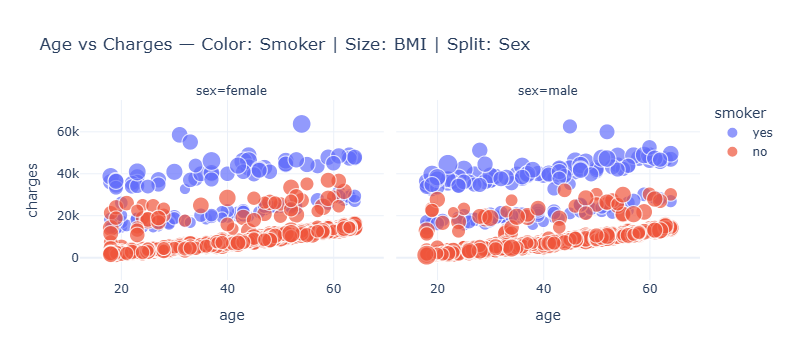

In [4]:
# Age vs charges — 4 dimensions in one chart
fig = px.scatter(
    df,
    x='age',
    y='charges',
    color='smoker',
    size='bmi',
    facet_col='sex',
    hover_data=['region', 'children'],
    title='Age vs Charges — Color: Smoker | Size: BMI | Split: Sex',
    template='plotly_white',
    opacity=0.7
)
fig.show()

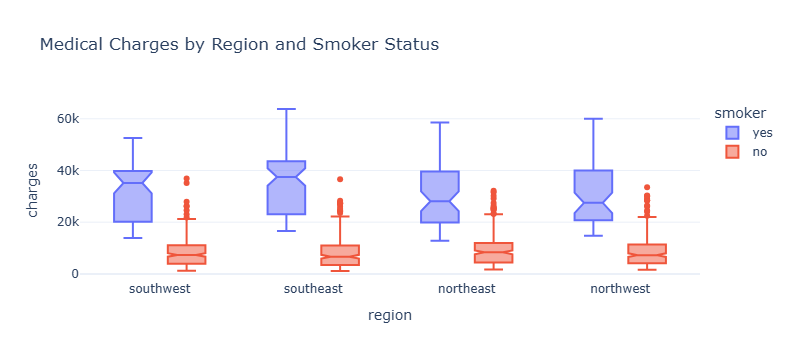

In [5]:
# Charges by region + smoker
fig = px.box(
    df,
    x='region',
    y='charges',
    color='smoker',
    notched=True,
    title='Medical Charges by Region and Smoker Status',
    template='plotly_white'
)
fig.show()

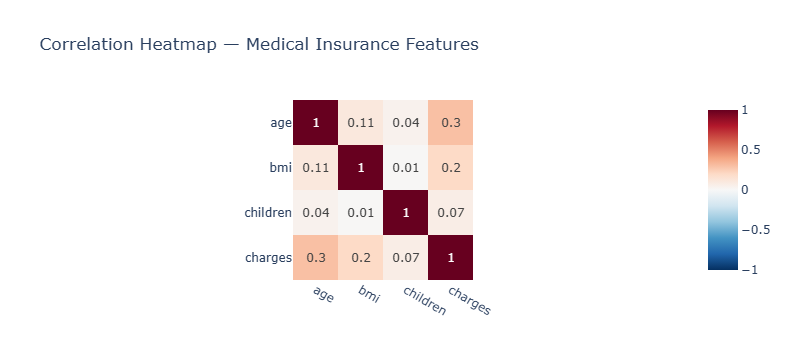

In [6]:
# Correlation matrix with hover
corr = df.select_dtypes(include='number').corr().round(2)
fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    title='Correlation Heatmap — Medical Insurance Features',
    zmin=-1, zmax=1
)
fig.show()

In [7]:
#Save all charts to one HTML file
with open('week2_eda_report.html', 'w') as f:
    f.write('<html><head><title>Week 2 EDA Report</title></head><body>')
    f.write('<h1 style="font-family:Arial">Week 2 EDA Report — Medical Insurance</h1>')
    figures = [
        ('Distribution of Charges', px.histogram(df, x='charges', color='smoker', template='plotly_white')),
        ('Age vs Charges', px.scatter(df, x='age', y='charges', color='smoker', template='plotly_white')),
        ('Charges by Region', px.box(df, x='region', y='charges', color='smoker', template='plotly_white')),
    ]
    for title, fig in figures:
        f.write(f'<h2 style="font-family:Arial">{title}</h2>')
        f.write(fig.to_html(full_html=False, include_plotlyjs='cdn'))
    f.write('</body></html>')
print('Report saved: week2_eda_report.html')

Report saved: week2_eda_report.html
